# EDA 02 — Selección secuencial de variables (SFS)

**Nota de alcance.** Esta exploración se realizó como **contraste del filtro univariante** del notebook `EDA_01_Spearman.ipynb`. No forma parte del pipeline final: la selección que alimenta el entrenamiento es la de Spearman + clustering de redundancia.

Se documenta aquí por dos razones: comprobar que el filtro univariante no dejaba fuera nada relevante por interacciones, y dejar constancia del criterio con el que se descartó. Va al **anexo**, no a la memoria.

## Contenido

- **0.** Configuración y candidatas
- **1.** Curva SFS: MAE vs. nº de variables
- **2.** Comparación con el top-k de Spearman
- **3.** Conclusión

## Por qué SFS, y por qué finalmente no

Spearman es un filtro univariante: mide cada variable por separado, así que es ciego a las **interacciones** (una variable puede ser inútil sola y valiosa acompañada). SFS es un *wrapper*: evalúa subconjuntos con el modelo real y sí las ve.

El problema es el coste: con $p$ candidatas y $k$ a seleccionar hace $kp - \frac{k(k-1)}{2}$ ajustes por fold. Sobre las 133 columnas originales es inviable.

---
## 0. Configuración y candidatas

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

try:
    from lightgbm import LGBMRegressor
    TIENE_LGBM = True
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    TIENE_LGBM = False
print("LightGBM disponible:", TIENE_LGBM)

LightGBM disponible: True


In [2]:
def raiz_proyecto(nombre="edev_models"):
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if c.name == nombre:
            return c
    raise FileNotFoundError(f"'{nombre}' no está en los padres de {p}")

ROOT = raiz_proyecto()
os.chdir(ROOT)

RUTA_MATRIZ = ROOT / "data" / "gold" / "matriz_nucleo.csv"
IN_SPEARMAN = ROOT / "eda" / "EDA_spearman_output"      # salida del notebook 01
OUT = ROOT / "eda" / "EDA_SFS_output"; OUT.mkdir(parents=True, exist_ok=True)

TARGET, FECHA = "target_price", "fecha_objetivo"
CORTE_TRAIN_VAL = "2025-12-31"
K_MAX, N_FOLDS, GAP = 12, 4, 24 * 7

**Dos decisiones que no son negociables en series temporales:**

1. `TimeSeriesSplit`, nunca `KFold`. Con validación cruzada aleatoria el modelo entrena con el 3 de marzo y valida con el 2 de marzo: se predice una hora usando el día siguiente. El MAE sale espectacular y el modelo no vale nada.
2. `gap` entre train y validación. Como hay lags de hasta D-6, se deja hueco para que el final del train no comparta información con el inicio de la validación.

In [3]:
df = pd.read_csv(RUTA_MATRIZ, parse_dates=[FECHA])
df = df[df[FECHA] <= CORTE_TRAIN_VAL].sort_values(FECHA).reset_index(drop=True)

reps = pd.read_csv(IN_SPEARMAN / "representantes_cluster.csv")
reps = reps[reps["frontera"] == "OK (pre-11:00)"]     # doble seguro
cands = [c for c in reps["variable"] if c in df.columns]

X, y = df[cands].astype(float), df[TARGET].astype(float)
print(f"{len(df):,} filas | {len(cands)} candidatas tras el filtro Spearman")

52,434 filas | 52 candidatas tras el filtro Spearman


In [4]:
def estimador(seed=42):
    # Modelo barato a proposito: el SFS busca el mejor SUBCONJUNTO,
    # no el mejor modelo.
    if TIENE_LGBM:
        return LGBMRegressor(n_estimators=150, learning_rate=0.1, num_leaves=31,
                             min_child_samples=50, random_state=seed,
                             n_jobs=-1, verbose=-1)
    return HistGradientBoostingRegressor(max_iter=150, random_state=seed)

def cv():
    return TimeSeriesSplit(n_splits=N_FOLDS, gap=GAP)

---
## 1. Curva SFS: MAE vs. nº de variables

In [5]:
def sfs_greedy(X, y, k_max=K_MAX, seed=42):
    restantes, elegidas, historia = list(X.columns), [], []
    for paso in range(1, k_max + 1):
        mejor, mejor_mae = None, np.inf
        for f in restantes:
            mae = -cross_val_score(estimador(seed), X[elegidas + [f]], y,
                                   scoring="neg_mean_absolute_error",
                                   cv=cv(), n_jobs=1).mean()
            if mae < mejor_mae:
                mejor, mejor_mae = f, mae
        elegidas.append(mejor); restantes.remove(mejor)
        delta = historia[-1]["mae"] - mejor_mae if historia else np.nan
        historia.append({"k": paso, "variable": mejor,
                         "mae": mejor_mae, "mejora": delta})
        print(f"  k={paso:2d}  {mejor:<34s} MAE={mejor_mae:7.3f}  d={delta:+.3f}")
    return pd.DataFrame(historia)

hist = sfs_greedy(X, y)
hist.to_csv(OUT / "curva_sfs.csv", index=False)

  k= 1  es_esios_Dm1                       MAE= 42.187  d=+nan
  k= 2  wind100_meteo                      MAE= 40.073  d=+2.114
  k= 3  d1_is_weekend                      MAE= 38.642  d=+1.431
  k= 4  wind_mw_Dm1                        MAE= 37.629  d=+1.013
  k= 5  d1_dow_cos                         MAE= 37.068  d=+0.560
  k= 6  ree_grenov_prev                    MAE= 36.500  d=+0.568
  k= 7  ree_gsolar_prev                    MAE= 35.980  d=+0.520
  k= 8  other_renewable_mw_Dm6             MAE= 35.239  d=+0.741
  k= 9  ree_netflow_pt_Dm1                 MAE= 35.084  d=+0.156
  k=10  d1_is_festivo                      MAE= 35.013  d=+0.071
  k=11  ventana_pisa_apagon                MAE= 35.013  d=+0.000
  k=12  pbf_publicado_D                    MAE= 35.013  d=+0.000


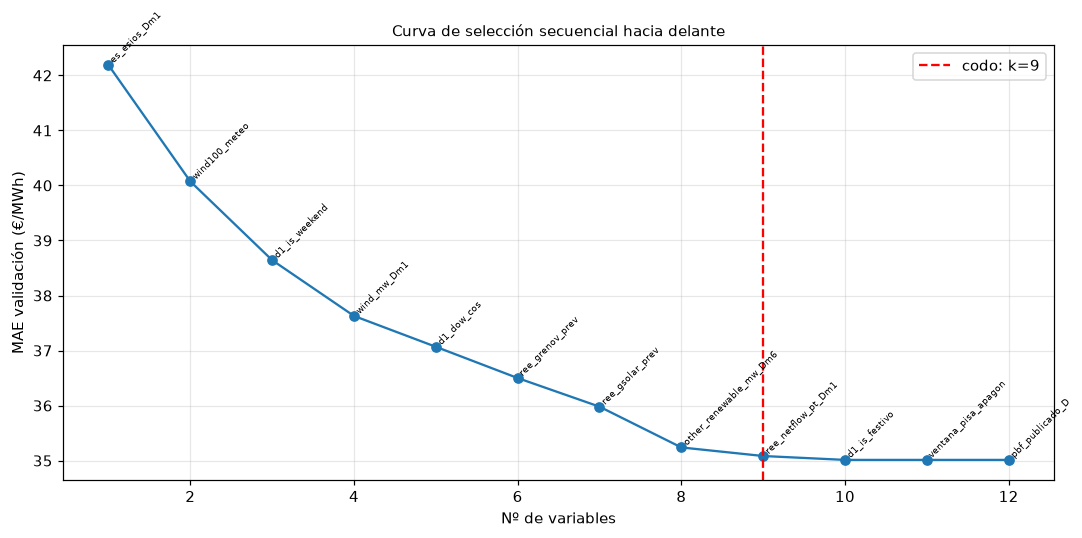

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist["k"], hist["mae"], "o-", color="#1f77b4")
for _, row in hist.iterrows():
    ax.annotate(row["variable"], (row["k"], row["mae"]),
                rotation=45, fontsize=6, ha="left", va="bottom")

umbral = 0.01 * hist["mae"].iloc[0]
c = hist[hist["mejora"] < umbral]["k"]
codo = int(c.min()) if len(c) else K_MAX
ax.axvline(codo, color="red", ls="--", label=f"codo: k={codo}")
ax.set_xlabel("Nº de variables"); ax.set_ylabel("MAE validación (€/MWh)")
ax.set_title("Curva de selección secuencial hacia delante", fontsize=10)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "01_curva_sfs.png", dpi=150); plt.show()

**Cuidado con una lectura tentadora.** La columna `mejora` *no* es una medida de importancia. Es la aportación **condicionada a lo ya seleccionado**: una variable excelente que entra en la posición 8 puede mostrar una mejora ínfima porque otra ya capturaba esa señal. Para importancia, SHAP sobre el modelo final.

---
## 2. Comparación con el top-k de Spearman

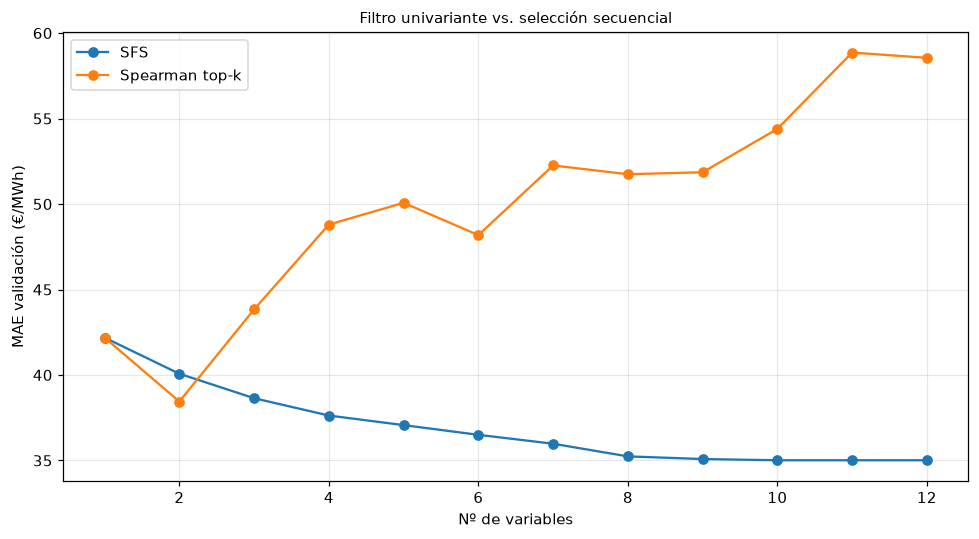

metodo     SFS  Spearman top-k  ganancia_sfs
k                                           
1       42.187          42.187         0.000
2       40.073          38.447        -1.626
3       38.642          43.835         5.193
4       37.629          48.800        11.171
5       37.068          50.072        13.004
6       36.500          48.182        11.682
7       35.980          52.257        16.277
8       35.239          51.745        16.505
9       35.084          51.859        16.775
10      35.013          54.395        19.382
11      35.013          58.862        23.849
12      35.013          58.553        23.540


In [7]:
rank = pd.read_csv(IN_SPEARMAN / "ranking_spearman.csv")
orden_sp  = rank[(rank.frontera == "OK (pre-11:00)") &
                 (rank.variable.isin(df.columns))] \
              .sort_values("abs_rho", ascending=False)["variable"].tolist()
orden_sfs = hist["variable"].tolist()

filas = []
for k in range(1, K_MAX + 1):
    for nombre, orden in [("Spearman top-k", orden_sp), ("SFS", orden_sfs)]:
        cols = [c for c in orden[:k] if c in df.columns]
        if len(cols) < k:
            continue
        mae = -cross_val_score(estimador(), df[cols].astype(float), y,
                               scoring="neg_mean_absolute_error",
                               cv=cv(), n_jobs=-1).mean()
        filas.append({"k": k, "metodo": nombre, "mae": mae})
comp = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(9, 5))
for m, g in comp.groupby("metodo"):
    ax.plot(g["k"], g["mae"], "o-", label=m)
ax.set_xlabel("Nº de variables"); ax.set_ylabel("MAE validación (€/MWh)")
ax.set_title("Filtro univariante vs. selección secuencial", fontsize=10)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "02_sfs_vs_spearman.png", dpi=150); plt.show()

piv = comp.pivot(index="k", columns="metodo", values="mae")
piv["ganancia_sfs"] = piv["Spearman top-k"] - piv["SFS"]
comp.to_csv(OUT / "sfs_vs_spearman.csv", index=False)
print(piv.round(3))

---
## 3. Conclusión

In [8]:
ganancia = piv.loc[codo, "ganancia_sfs"]
mae_sp   = piv.loc[codo, "Spearman top-k"]
print(f"Con k={codo}:")
print(f"  MAE Spearman top-k : {mae_sp:.3f} €/MWh")
print(f"  MAE SFS            : {piv.loc[codo,'SFS']:.3f} €/MWh")
print(f"  Ganancia del SFS   : {ganancia:.3f} €/MWh ({ganancia/mae_sp:.1%})")
print("\nSelección SFS:")
print(orden_sfs[:codo])

Con k=9:
  MAE Spearman top-k : 51.859 €/MWh
  MAE SFS            : 35.084 €/MWh
  Ganancia del SFS   : 16.775 €/MWh (32.3%)

Selección SFS:
['es_esios_Dm1', 'wind100_meteo', 'd1_is_weekend', 'wind_mw_Dm1', 'd1_dow_cos', 'ree_grenov_prev', 'ree_gsolar_prev', 'other_renewable_mw_Dm6', 'ree_netflow_pt_Dm1']


### Por qué no se aplicó al pipeline final

A simple vista el SFS tiene una gran ganancia frente a solo utilizar spearman. Pero cuando ambos se aplican al proyecto real, en producción los resultados varían. Primero se encuentra que la diferencia entre utilizar Spearman + SFS, no es tan grande como la que se presenta en este notebook, el cual no cuenta con los mismos modelos. Segundo el SFS tiene un problema más grande que las ganancias que este pueda crear. Al aplicar ambos métodos sobre el proyecto final se encuentra un severo problema, ejecutar la selección de variables dura más de 1 hora y media. Una cantidad de tiempo fuera del rango esperado para la respuesta de los modelos a nivel de producción. Se determina que el culpable de esta demora es el SFS, el cual tiene un coste computacional demasiado alto.

